In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
from forecasting_utils import PROCESSED_DIR

# Evaluation  

This notebook pulls the model results together so I can compare what actually held up and what just looked promising in isolation.

Pretty simple idea here: line up the metrics, check the plots, and be honest about which approach feels most usable.


In [3]:
stat_metrics = pd.read_csv(PROCESSED_DIR / "statistical_model_metrics.csv")
sup_metrics = pd.read_csv(PROCESSED_DIR / "supervised_model_metrics.csv")

all_metrics = pd.concat([stat_metrics, sup_metrics], ignore_index=True)
all_metrics.sort_values(["rmse", "mae"])

,model,mae,rmse,mape
1,Month-Day Baseline (2026 test),0.090297,0.501941,98.000000
3,PoissonRegressor (2026 test),0.186841,0.537021,96.650029
10,XGBoost (2026 test),0.166773,0.555234,99.187980
6,LinearRegression (2026 test),0.268220,0.621684,94.877183
4,SARIMAX (2026 test),0.360679,0.714002,87.760886
8,RandomForest (2026 test),0.319929,0.717576,98.416362
7,RandomForest (2025 validation),1.902518,3.426729,78.439838
5,LinearRegression (2025 validation),1.899498,3.472053,78.761486
9,XGBoost (2025 validation),1.941450,3.526612,85.795789
2,PoissonRegressor (2025 validation),1.988470,3.709722,92.439094


## Overall Metrics

This first table is the broad ranking view. It's the fast way to see which models stayed competitive once everything is lined up together.


In [4]:
test_metrics = all_metrics.loc[all_metrics["model"].str.contains("2026 test")].copy()
test_metrics = test_metrics.sort_values(["rmse", "mae"]).reset_index(drop=True)
test_metrics

,model,mae,rmse,mape
0,Month-Day Baseline (2026 test),0.090297,0.501941,98.000000
1,PoissonRegressor (2026 test),0.186841,0.537021,96.650029
2,XGBoost (2026 test),0.166773,0.555234,99.187980
3,LinearRegression (2026 test),0.268220,0.621684,94.877183
4,SARIMAX (2026 test),0.360679,0.714002,87.760886
5,RandomForest (2026 test),0.319929,0.717576,98.416362


## Metric Comparison Plot

Same idea as the table, just easier to scan visually. I'm mostly using this to see whether one model is clearly better or if they're all clustered together.


C:\Users\Owner\AppData\Local\Temp\ipykernel_39784\3424292824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_metrics, x="rmse", y="model", palette="viridis")


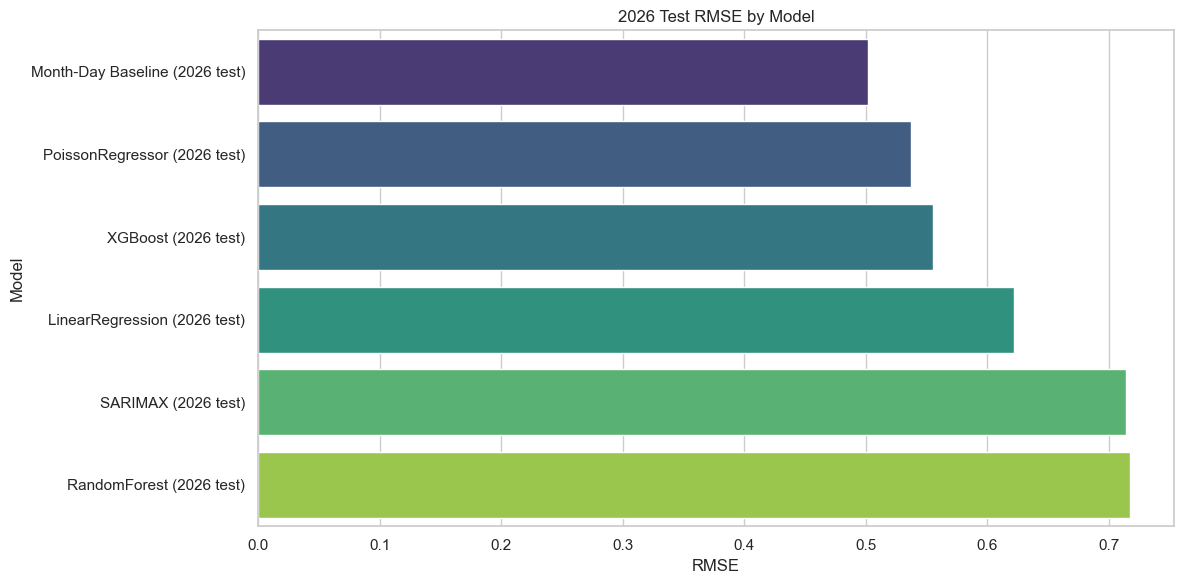

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(data=test_metrics, x="rmse", y="model", palette="viridis")
plt.title("2026 Test RMSE by Model")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [6]:
stat_preds = pd.read_csv(PROCESSED_DIR / "statistical_model_predictions.csv", parse_dates=["admission_date"])
sup_preds = pd.read_csv(PROCESSED_DIR / "supervised_model_predictions.csv", parse_dates=["admission_date"])

In [7]:
merged = stat_preds.merge(
    sup_preds.drop(columns=["arrivals"]),
    on="admission_date",
    how="inner",
)

In [8]:
observed_merged = merged.loc[merged["arrivals"].notna()].copy()
merged.head()

,admission_date,arrivals,baseline_pred,poisson_pred,sarimax_pred,LinearRegression_pred,RandomForest_pred,XGBoost_pred
0,2026-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Observed Vs Predicted Arrivals

This plot is where I sanity-check model behavior on the observed window. I want to see whether the timing and magnitude feel reasonable, not just whether the error numbers are low.


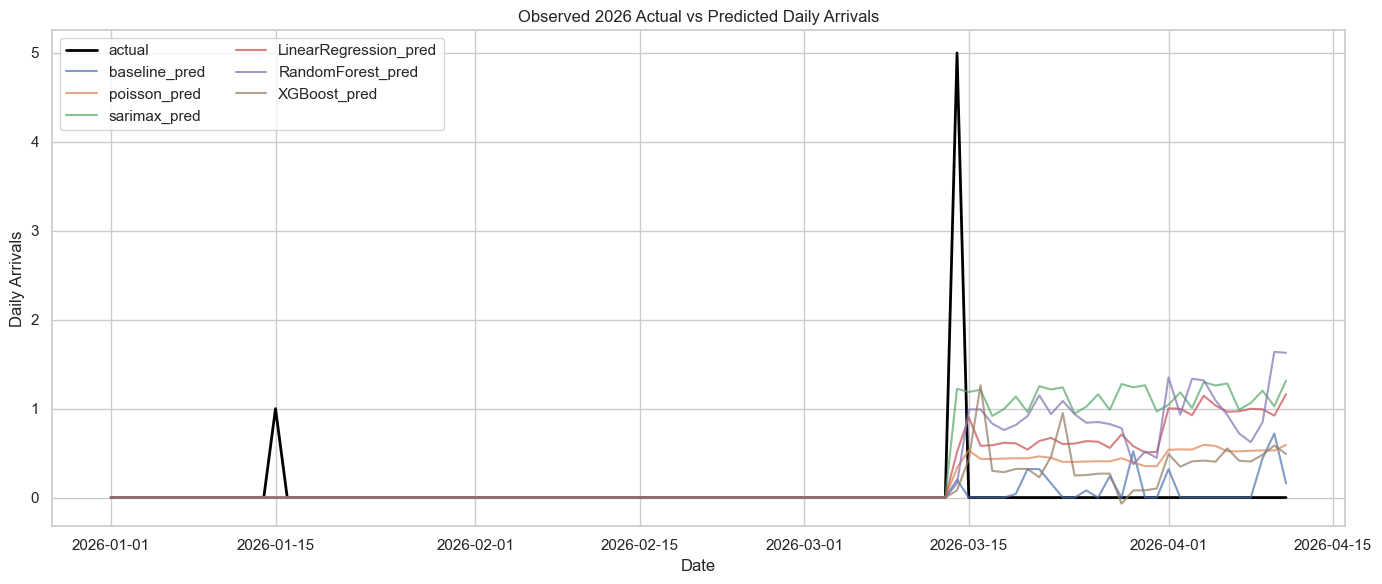

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(observed_merged["admission_date"], observed_merged["arrivals"], label="actual", linewidth=2, color="black")
for column in observed_merged.columns:
    if column.endswith("_pred") or column in {"baseline_pred", "poisson_pred", "sarimax_pred"}:
        plt.plot(observed_merged["admission_date"], observed_merged[column], label=column, alpha=0.7)
plt.title("Observed 2026 Actual vs Predicted Daily Arrivals")
plt.xlabel("Date")
plt.ylabel("Daily Arrivals")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### Daily Arrival Probability By Model

The models forecast expected daily arrivals rather than direct probabilities, so for presentation we convert each model's daily forecast into a probability distribution across the full forecast window by dividing each day's non-negative prediction by that model's total predicted arrivals.

If a model has only one day with a positive forecast after the seasonal cutoff, that day will mechanically receive probability `1.0`. In that case the probability plot is not very informative, and the raw expected-arrivals plot above is the better interpretation.


In [10]:
prediction_cols = [
    "baseline_pred",
    "poisson_pred",
    "sarimax_pred",
    "LinearRegression_pred",
    "RandomForest_pred",
    "XGBoost_pred",
]

In [11]:
probability_df = merged[["admission_date"] + prediction_cols].copy()
probability_df[prediction_cols] = probability_df[prediction_cols].clip(lower=0)

## Probability Diagnostics

This table reframes the forecasts as a day-by-day probability share of total arrivals. It helps show whether a model spreads arrivals out or dumps them onto one day.


In [12]:
probability_diagnostic = pd.DataFrame(
    {
        "model": prediction_cols,
        "nonzero_days": [(probability_df[column] > 0).sum() for column in prediction_cols],
        "total_predicted_arrivals": [probability_df[column].sum() for column in prediction_cols],
    }
).sort_values(["nonzero_days", "total_predicted_arrivals"], ascending=[False, False])

probability_diagnostic

,model,nonzero_days,total_predicted_arrivals
4,RandomForest_pred,80,450.068079
3,LinearRegression_pred,80,121.139400
2,sarimax_pred,80,63.887737
1,poisson_pred,80,37.847263
5,XGBoost_pred,79,352.681345
0,baseline_pred,63,123.212308


In [13]:
for column in prediction_cols:
    total_pred = probability_df[column].sum()
    probability_df[column] = 0.0 if total_pred == 0 else probability_df[column] / total_pred

In [14]:
probability_long = probability_df.melt(
    id_vars="admission_date",
    value_vars=prediction_cols,
    var_name="model",
    value_name="daily_probability",
)

In [15]:
peak_probability = (
    probability_long.sort_values(["model", "daily_probability"], ascending=[True, False])
    .groupby("model", as_index=False)
    .first()
    .sort_values("daily_probability", ascending=False)
)
peak_probability

,model,admission_date,daily_probability
2,XGBoost_pred,2026-05-04,0.037842
3,baseline_pred,2026-05-28,0.032152
1,RandomForest_pred,2026-05-07,0.029615
5,sarimax_pred,2026-04-11,0.020594
0,LinearRegression_pred,2026-05-09,0.020250
4,poisson_pred,2026-04-04,0.015683


In [16]:
models_with_multiple_days = probability_diagnostic.loc[
    probability_diagnostic["nonzero_days"] > 1, "model"
]

probability_plot_df = probability_long.loc[
    probability_long["model"].isin(models_with_multiple_days)
]

peak_probability_plot = peak_probability.loc[
    peak_probability["model"].isin(models_with_multiple_days)
]


## Arrival Probability Plot

This is the more story-driven view of the forecast timing. If the lines look too spiky or collapse into a single day, that usually tells me the model is being a little too rigid.


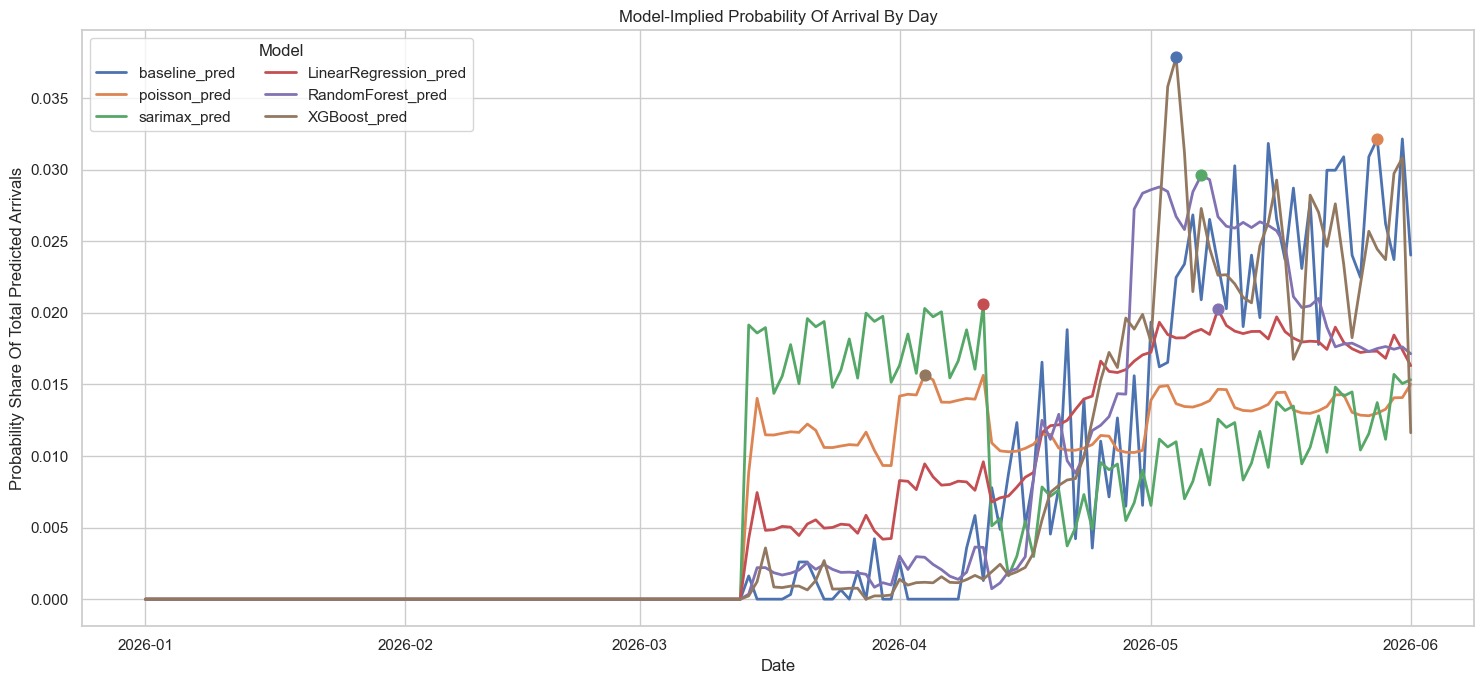

In [17]:
plt.figure(figsize=(15, 7))
if probability_plot_df.empty:
    plt.text(
        0.5,
        0.5,
        "All models have only one nonzero forecast day after the seasonal cutoff.Use the raw expected-arrivals plot above or extend the forecast horizon.",
        ha="center",
        va="center",
        transform=plt.gca().transAxes,
        fontsize=12,
    )
    plt.axis("off")
else:
    sns.lineplot(
        data=probability_plot_df,
        x="admission_date",
        y="daily_probability",
        hue="model",
        linewidth=2,
    )

    for row in peak_probability_plot.itertuples(index=False):
        plt.scatter(row.admission_date, row.daily_probability, s=60, zorder=5)

plt.title("Model-Implied Probability Of Arrival By Day")
plt.xlabel("Date")
plt.ylabel("Probability Share Of Total Predicted Arrivals")
if not probability_plot_df.empty:
    plt.legend(title="Model", ncol=2)
plt.tight_layout()
plt.show()